## Problem 1 (a)


In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import math
rc('axes', fc='w')
rc('figure', fc='w')
rc('savefig', fc='w')
rc('axes', axisbelow=True)

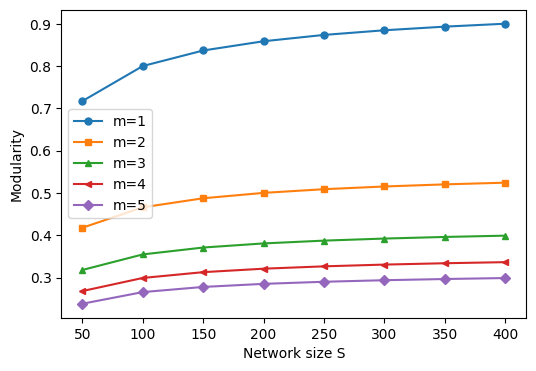

In [3]:
a = 0.165
S = np.arange(50, 430, 50)
m = [1, 2, 3, 4, 5]

def calculate_msf(a, S, m):
    msf_i = (a + (1 - a) / m) * (1 - 2/np.sqrt(S))
    return msf_i

styles = {
    1: {'marker': 'o', 'linestyle': '-', 'label': 'm=1'},
    2: {'marker': 's', 'linestyle': '-', 'label': 'm=2'},
    3: {'marker': '^', 'linestyle': '-', 'label': 'm=3'},
    4: {'marker': '<', 'linestyle': '-', 'label': 'm=4'},
    5: {'marker': 'D', 'linestyle': '-', 'label': 'm=5'}
}

plt.figure(figsize=(6,4))
for m_i in m:
    plt.plot(
        S,
        calculate_msf(a, S, m_i),
        **styles[m_i],
        markersize=5,
        linewidth=1.5
    )
    
plt.xlabel('Network size S')
plt.ylabel('Modularity')
plt.legend()
plt.show()

## part b

In [4]:
import graph_tool.all as gt

In [5]:
g = gt.collection.ns["polblogs"]
g = gt.extract_largest_component(g, directed=False)

In [6]:
# Shared layout so visual comparisons are meaningful
pos = gt.sfdp_layout(g)

# Non-degree-corrected SBM with exactly 2 blocks
state_ndc = gt.minimize_blockmodel_dl(
    g,
    state_args=dict(deg_corr=False, B=2)
)
b_ndc = state_ndc.get_blocks()

gt.graph_draw(
    g,
    pos=pos,
    vertex_fill_color=b_ndc,
    vertex_size=5,
    edge_pen_width=0.3,
    edge_color=(0, 0, 0, 0.2),
    output_size=(600, 600),
    output="polblogs_sbm_ndc_B2.png"
)

# Degree-corrected SBM with exactly 2 blocks
state_dc = gt.minimize_blockmodel_dl(
    g,
    state_args=dict(deg_corr=True, B=2)
)
b_dc = state_dc.get_blocks()

gt.graph_draw(
    g,
    pos=pos,
    vertex_fill_color=b_dc,
    vertex_size=5,
    edge_pen_width=0.3,
    edge_color=(0, 0, 0, 0.2),
    output_size=(600, 600),
    output="polblogs_sbm_dc_B2.png"
)


<VertexPropertyMap object with value type 'vector<double>', for Graph 0x115e0a850, at 0x1645258d0>

## part c

In [7]:
print("Non-degree-corrected SBM (B=2) description length:", state_ndc.entropy())
print("Degree-corrected SBM (B=2) description length:", state_dc.entropy())


Non-degree-corrected SBM (B=2) description length: 63692.28699797146
Degree-corrected SBM (B=2) description length: 61076.889367501455


<>:46: SyntaxWarning: invalid escape sequence '\S'
<>:46: SyntaxWarning: invalid escape sequence '\S'
/var/folders/2c/064zj4311gvb_kh76pglwwn40000gn/T/ipykernel_62810/1019326211.py:46: SyntaxWarning: invalid escape sequence '\S'
  plt.ylabel("Description length $\Sigma$")


Initial (non-degree-corrected) DL: 103142.51578138037
Initial (degree-corrected) DL: 71937.2866322653
Final non-degree-corrected B: 16
Final degree-corrected B: 6


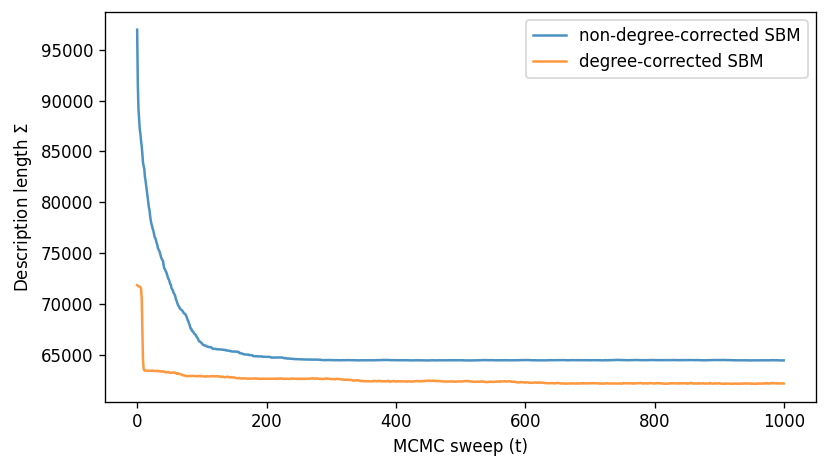

In [8]:
# ---------------------------------------
# Load largest connected component again
# (or reuse g from part (b))
# ---------------------------------------
g = gt.collection.ns["polblogs"]
g = gt.extract_largest_component(g, directed=False, prune=True)

# ---------------------------------------
# Initialize BlockState with B=2
# ---------------------------------------
state_ndc_mcmc = gt.BlockState(g, B=2, deg_corr=False)
state_dc_mcmc  = gt.BlockState(g, B=2, deg_corr=True)

print("Initial (non-degree-corrected) DL:", state_ndc_mcmc.entropy())
print("Initial (degree-corrected) DL:", state_dc_mcmc.entropy())

# ---------------------------------------
# Run MCMC sweeps and record description lengths
# ---------------------------------------
n_steps = 1000

dl_ndc_traj = np.zeros(n_steps)
dl_dc_traj  = np.zeros(n_steps)

for t in range(n_steps):
    # One sweep per step (niter=1)
    state_ndc_mcmc.mcmc_sweep(niter=1)
    dl_ndc_traj[t] = state_ndc_mcmc.entropy()
    
    state_dc_mcmc.mcmc_sweep(niter=1)
    dl_dc_traj[t] = state_dc_mcmc.entropy()

# Optionally check how many blocks you ended up with
print("Final non-degree-corrected B:", state_ndc_mcmc.get_nonempty_B())
print("Final degree-corrected B:", state_dc_mcmc.get_nonempty_B())

# ---------------------------------------
# Plot the trajectories
# ---------------------------------------
plt.figure(figsize=(7,4), dpi=120)

plt.plot(dl_ndc_traj, label="non-degree-corrected SBM", alpha=0.8)
plt.plot(dl_dc_traj,  label="degree-corrected SBM", alpha=0.8)

plt.xlabel("MCMC sweep (t)")
plt.ylabel("Description length $\Sigma$")
plt.legend()
plt.tight_layout()
plt.show()